In [1]:
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [ ]:
#check lapdata.pkl

In [13]:
pipeline = joblib.load('lapdata.pkl')

In [12]:
import joblib
try:
    pipeline = joblib.load('lapdata.pkl')
    print(f"Loaded object type: {type(pipeline)}") 
except FileNotFoundError:
    print("Error: The model file was not found. Please ensure 'trained_laptop_model_pipeline.pkl' exists.")


Loaded object type: <class 'sklearn.pipeline.Pipeline'>


In [14]:
X_test = pd.read_csv("splits/X_test.csv")
y_test = pd.read_csv("splits/y_test.csv")

In [15]:
y_pred = pipeline.predict(X_test)

In [16]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 0.2130
MAE: 0.1648
R²: 0.8810
Adjusted R²: 0.8751
MAPE: 1.51%


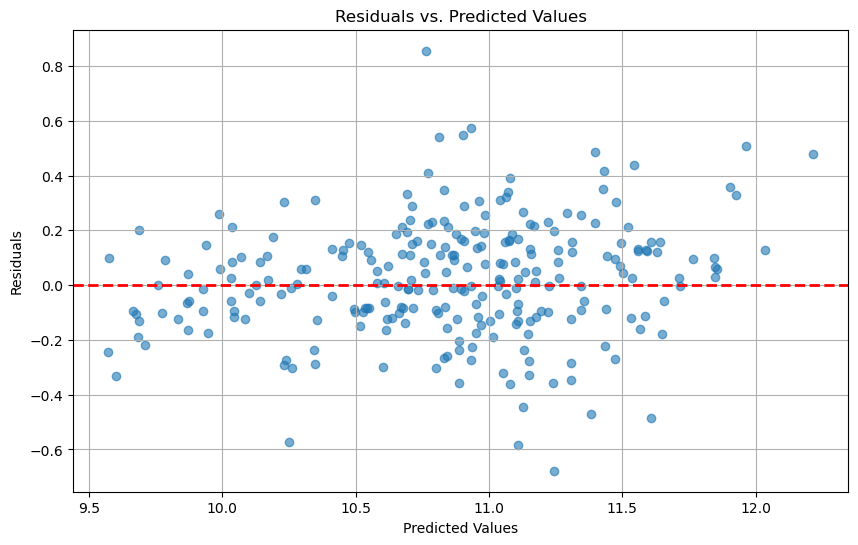

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2) # Line at zero residuals
plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()